# 04 · Vegetation fragmentation

**Question:** Besides removing vegetation, did the highway **break up** the vegetation that remained, into smaller and more isolated patches?

**Mirrors script:** `python/05_fragmentation.py`.
**Inputs:** land-cover maps `data/rasters/LC_DS{2020,2024,2026}_{S1,W,E}.tif`, units `data/vectors/segment_zones_all.shp`, matching weights `results/seg_cov_w.csv` (notebook 03).
**Outputs:** `results/fragmentation_by_unit.csv`, `fragmentation_summary.csv`, `fragmentation_did.csv`.

### Why "vegetation" and not "mangrove"
The classification does not separate mangrove from other vegetation (it cannot do so reliably at 10 m), so fragmentation is measured for **all vegetation**. Calling it mangrove fragmentation would overstate what the maps show.

### Landscapes
Fragmentation is measured per segment in three "landscapes":

| Landscape | Zones | Why |
|---|---|---|
| **Corridor** | footprint + 0–500 m | the road runs *through* this landscape, so patches it splits are captured |
| 500 m–1 km | B2 | near surroundings |
| 1–5 km | B3 | wider surroundings |

In [1]:
# --- Setup: find the repository folders (works from notebooks/ or the repo root) ---
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
from paths import DATA, VEC, RAS, TAB, VAL, RES, ZONES, CRS   # shared folder locations
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Repository root found:', ROOT.name)

Repository root found: lagos-calabar-s1-vegetation-loss


In [2]:
LC_NAMES = {1: 'Vegetation', 2: 'Sand / bare', 3: 'Beach', 4: 'Built-up', 5: 'Water'}
LC_COLS  = {0: '#FFFFFF', 1: '#2E7D32', 2: '#E8A87C', 3: '#FFF2B3', 4: '#D7301F', 5: '#C6DBEF'}
from matplotlib.colors import ListedColormap, BoundaryNorm
LC_CMAP = ListedColormap([LC_COLS[i] for i in range(6)])
LC_NORM = BoundaryNorm(np.arange(-0.5, 6.5), 6)

## 1. Patch metrics

A **patch** is a group of vegetation pixels connected through any of their 8 neighbours. Patches smaller than **0.1 ha (10 pixels)** are removed first, so single misclassified pixels do not count as patches. Five metrics follow McGarigal (2015, FRAGSTATS):

| Metric | Meaning | Fragmentation shows as |
|---|---|---|
| **PLAND** | % of land that is vegetation | ↓ |
| **PD** | number of patches per 100 ha of land | ↑ |
| **MPA** | mean patch area (ha) | ↓ |
| **ED** | edge between vegetation and other cover, m per ha of land (10 m per pixel side) | ↑ |
| **LPI** | largest patch as % of land | ↓ |

"Land" excludes water, so a unit that is half sea is not penalised.

In [3]:
import geopandas as gpd, rasterio
from rasterio import features
from scipy import ndimage

YEARS, MIN_PX, PX_HA = [2020, 2024, 2026], 10, 0.01
EIGHT = np.ones((3, 3), int)

def metrics(lc, mask, return_patches=False):
    land = mask & (lc >= 1) & (lc <= 4)
    n_land = land.sum()
    if n_land == 0:
        return None
    veg = mask & (lc == 1)
    lab, n = ndimage.label(veg, structure=EIGHT)                       # 8-neighbour patches
    sizes = ndimage.sum(veg, lab, index=np.arange(1, n + 1))
    veg = np.isin(lab, np.where(sizes >= MIN_PX)[0] + 1)                # drop patches < 0.1 ha
    sizes = sizes[sizes >= MIN_PX]
    mh, mv = mask[:, :-1] & mask[:, 1:], mask[:-1, :] & mask[1:, :]
    edges = ((veg[:, :-1] != veg[:, 1:]) & mh).sum() + ((veg[:-1, :] != veg[1:, :]) & mv).sum()
    land_ha = n_land * PX_HA
    out = dict(land_ha=land_ha, veg_ha=veg.sum() * PX_HA, PLAND=100 * veg.sum() / n_land,
               NP=len(sizes), PD=100 * len(sizes) / land_ha,
               MPA=(sizes.mean() * PX_HA) if len(sizes) else np.nan,
               ED=edges * 10 / land_ha, LPI=(100 * sizes.max() / n_land) if len(sizes) else 0.0)
    return (out, np.where(veg, ndimage.label(veg, structure=EIGHT)[0], 0)) if return_patches else out

## 2. Build the landscapes

In [4]:
z = gpd.read_file(VEC / 'segment_zones_all.shp').to_crs(32631)
z['land'] = z.zone.map({'F': 'corridor', 'B1': 'corridor', 'B2': 'B2', 'B3': 'B3'})
units = z.dissolve(by=['seg_id', 'land'], as_index=False)[['seg_id', 'land', 'side', 'treated', 'geometry']]
print(units.groupby(['side', 'land']).size().unstack())

land  B2  B3  corridor
side                  
E     44  44        44
S1    47  47        47
W     66  66        66


## 3. An example: one Section 1 corridor before and during construction

Segment **T33** (eastern Section 1). Each colour is one vegetation patch.

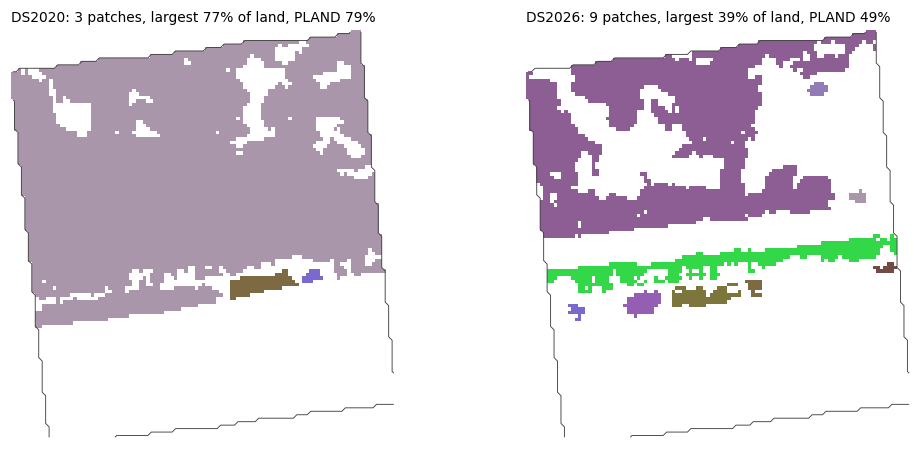

In [5]:
from matplotlib.colors import ListedColormap
u = units[units.side == 'S1'].reset_index(drop=True)
i = u.index[(u.seg_id == 'T33') & (u.land == 'corridor')][0]
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))
rng_c = np.random.default_rng(3); pal = ListedColormap(['#FFFFFF'] + list(rng_c.uniform(0.15, 0.85, (400, 3))))
for ax, y in zip(axs, [2020, 2026]):
    with rasterio.open(RAS / f'LC_DS{y}_S1.tif') as r:
        lc = r.read(1)
        idx = features.rasterize([(u.geometry[i], 1)], out_shape=lc.shape, transform=r.transform, fill=0, dtype='uint8')
    rows_, cols_ = np.where(idx == 1); sl = (slice(rows_.min(), rows_.max() + 1), slice(cols_.min(), cols_.max() + 1))
    m, patches = metrics(lc[sl], idx[sl] == 1, return_patches=True)
    ax.imshow(np.where(idx[sl] == 1, patches % 400, 0), cmap=pal, interpolation='nearest')
    ax.contour(idx[sl], levels=[0.5], colors='#444', linewidths=0.6)
    ax.set_title(f'DS{y}: {m["NP"]} patches, largest {m["LPI"]:.0f}% of land, PLAND {m["PLAND"]:.0f}%', fontsize=9, loc='left')
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 4. Compute the metrics for every landscape and year

Each side's raster is read once per year; the landscapes are burnt into a grid of unit ids and processed one by one. (About 10 seconds.)

In [6]:
rows = []
for side in ['S1', 'W', 'E']:
    u = units[units.side == side].reset_index(drop=True)
    for y in YEARS:
        with rasterio.open(RAS / f'LC_DS{y}_{side}.tif') as r:
            lc = r.read(1)
            idx = features.rasterize(((g, k + 1) for k, g in enumerate(u.geometry)),
                                     out_shape=lc.shape, transform=r.transform, fill=0, dtype='int32')
        for k, sl in enumerate(ndimage.find_objects(idx)):
            if sl is None: continue
            m = metrics(lc[sl], idx[sl] == k + 1)
            if m:
                rows.append(dict(seg_id=u.seg_id[k], land=u.land[k], side=side, treated=int(u.treated[k]), year=y, **m))
fr = pd.DataFrame(rows); fr.to_csv(RES / 'fragmentation_by_unit.csv', index=False)
print(fr.shape); fr.head()

(1413, 13)


,seg_id,land,side,treated,year,land_ha,veg_ha,PLAND,NP,PD,MPA,ED,LPI
0,T01,B2,S1,1,2020,210.08,1.09,0.518850,4,1.904037,0.272500,7.806550,0.223724
1,T01,B3,S1,1,2020,2667.76,184.13,6.902045,185,6.934657,0.995297,48.771254,1.211128
2,T01,corridor,S1,1,2020,135.52,7.54,5.563754,9,6.641086,0.837778,44.495277,3.623081
3,T02,B2,S1,1,2020,53.12,0.00,0.000000,0,0.000000,NaN,0.000000,0.000000
4,T02,B3,S1,1,2020,262.84,11.85,4.508446,37,14.077005,0.320270,57.259169,0.612540


## 5. Section 1 vs matched controls

Only landscapes with at least 1 ha of vegetation in 2020 are used, and only the matched segments from notebook 03, weighted by their matching weights.

In [7]:
w = pd.read_csv(RES / 'seg_cov_w.csv')[['seg_id', 'match_w']]
fr = fr.merge(w, on='seg_id', how='left').fillna({'match_w': 0})
base = fr[fr.year == 2020][['seg_id', 'land', 'veg_ha']].rename(columns={'veg_ha': 'veg2020'})
fr = fr.merge(base, on=['seg_id', 'land']); fr = fr[fr.veg2020 >= 1.0]
m = fr[fr.match_w > 0]
M = ['PLAND', 'PD', 'MPA', 'ED', 'LPI']
summ = []
for land in ['corridor', 'B2', 'B3']:
    for y in YEARS:
        for t in [1, 0]:
            s = m[(m.land == land) & (m.year == y) & (m.treated == t)]
            vals = {k: np.average(s.loc[s[k].notna(), k], weights=s.loc[s[k].notna(), 'match_w']) for k in M}
            summ.append(dict(landscape=land, year=y, group='Section 1' if t else 'Matched controls', n=len(s), **vals))
summ = pd.DataFrame(summ); summ.to_csv(RES / 'fragmentation_summary.csv', index=False)
summ.round(2)

,landscape,year,group,n,PLAND,PD,MPA,ED,LPI
0,corridor,2020,Section 1,22,70.96,4.11,29.77,69.27,66.13
1,corridor,2020,Matched controls,21,43.53,9.12,13.15,149.12,35.17
2,corridor,2024,Section 1,22,61.72,5.43,16.83,97.85,57.94
3,corridor,2024,Matched controls,21,41.92,7.90,15.69,154.53,33.97
4,corridor,2026,Section 1,22,52.35,7.42,9.37,115.59,42.42
5,corridor,2026,Matched controls,21,41.20,8.63,15.36,161.08,33.01
6,B2,2020,Section 1,22,93.31,2.95,40.01,36.77,92.77
7,B2,2020,Matched controls,20,74.35,12.38,16.85,138.30,67.11
8,B2,2024,Section 1,22,86.89,3.72,33.09,74.33,83.76
9,B2,2024,Matched controls,20,73.90,12.17,17.33,137.01,67.64


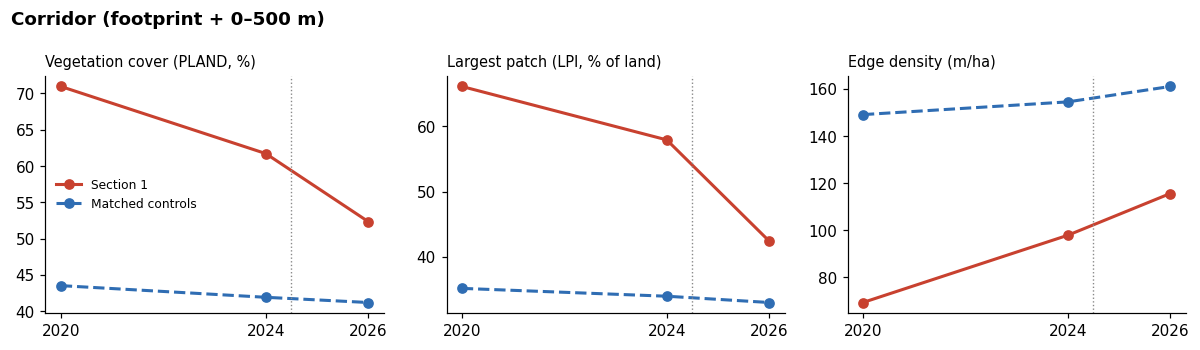

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, k, lab in zip(axs, ['PLAND', 'LPI', 'ED'], ['Vegetation cover (PLAND, %)', 'Largest patch (LPI, % of land)', 'Edge density (m/ha)']):
    s = summ[summ.landscape == 'corridor']
    for g_, col, ls in [('Section 1', '#C8412F', '-'), ('Matched controls', '#2F6DB3', '--')]:
        q = s[s.group == g_]; ax.plot(q.year, q[k], color=col, ls=ls, marker='o', lw=2, label=g_)
    ax.axvline(2024.5, color='#888', ls=':', lw=0.9); ax.set_title(lab, fontsize=9.5, loc='left'); ax.set_xticks(YEARS)
axs[0].legend(frameon=False, fontsize=8); fig.suptitle('Corridor (footprint + 0–500 m)', x=0.01, ha='left', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Difference-in-differences on each metric

Same model as notebook 03, with three time points and DS2024 as the reference:

$$\text{metric}_{it} = \alpha_i + \lambda_t + \gamma_{2020}\,(T_i \times \mathbb 1[t=2020]) + \gamma_{2026}\,(T_i \times \mathbb 1[t=2026]) + \varepsilon_{it}$$

* $\gamma_{2026}$ = extra change in Section 1 **during construction** (2024 → 2026), relative to controls;
* $-\gamma_{2020}$ = extra change **before construction** (2020 → 2024), a pre-construction check.

Weighted by the matching weights; standard errors clustered by segment.

In [9]:
import statsmodels.api as sm
res = []
for land in ['corridor', 'B2', 'B3']:
    s = m[m.land == land].copy(); s['uid'] = s.seg_id + '_' + s.land
    for k in M:
        s2 = s.dropna(subset=[k]).reset_index(drop=True)
        X = pd.concat([pd.DataFrame({'t2020': ((s2.year == 2020) & (s2.treated == 1)).astype(float),
                                     't2026': ((s2.year == 2026) & (s2.treated == 1)).astype(float)}),
                       pd.get_dummies(s2.uid, dtype=float), pd.get_dummies(s2.year, prefix='yr', drop_first=True, dtype=float)], axis=1)
        fit = sm.WLS(s2[k].astype(float), X, weights=s2.match_w).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(s2.seg_id)[0]})
        ci = fit.conf_int(); n1, n0 = s2[s2.treated == 1].seg_id.nunique(), s2[s2.treated == 0].seg_id.nunique()
        res.append(dict(landscape=land, metric=k, term='Before construction (2020→2024)', estimate=-fit.params['t2020'],
                        ci_low=-ci.loc['t2020', 1], ci_high=-ci.loc['t2020', 0], p=fit.pvalues['t2020'], n_S1=n1, n_ctrl=n0))
        res.append(dict(landscape=land, metric=k, term='Construction (2024→2026)', estimate=fit.params['t2026'],
                        ci_low=ci.loc['t2026', 0], ci_high=ci.loc['t2026', 1], p=fit.pvalues['t2026'], n_S1=n1, n_ctrl=n0))
res = pd.DataFrame(res); res.to_csv(RES / 'fragmentation_did.csv', index=False)
res.round(3)

,landscape,metric,term,estimate,ci_low,ci_high,p,n_S1,n_ctrl
0,corridor,PLAND,Before construction (2020→2024),-7.633,-13.183,-2.084,0.007,22,21
1,corridor,PLAND,Construction (2024→2026),-8.648,-12.621,-4.676,0.000,22,21
2,corridor,PD,Before construction (2020→2024),2.543,-1.010,6.095,0.161,22,21
3,corridor,PD,Construction (2024→2026),1.259,-0.841,3.358,0.240,22,21
4,corridor,MPA,Before construction (2020→2024),-15.469,-29.646,-1.291,0.032,22,21
5,corridor,MPA,Construction (2024→2026),-7.140,-15.826,1.546,0.107,22,21
6,corridor,ED,Before construction (2020→2024),23.170,-0.110,46.451,0.051,22,21
7,corridor,ED,Construction (2024→2026),11.190,-4.429,26.810,0.160,22,21
8,corridor,LPI,Before construction (2020→2024),-6.988,-12.925,-1.052,0.021,22,21
9,corridor,LPI,Construction (2024→2026),-14.556,-20.404,-8.709,0.000,22,21


In [10]:
# the construction-period effects only, flagged when p < 0.05
c = res[res.term.str.startswith('Construction')].copy()
c['significant'] = np.where(c.p < 0.05, 'yes', '')
c.pivot(index='metric', columns='landscape', values='estimate')[['corridor', 'B2', 'B3']].round(2)

landscape,corridor,B2,B3
metric,,,
ED,11.19,-7.80,-5.71
LPI,-14.56,-4.26,-1.54
MPA,-7.14,-1.52,0.47
PD,1.26,-1.52,-0.01
PLAND,-8.65,-3.80,-0.43


## Interpretation

* **In the corridor the road split the vegetation.** During construction the largest patch shrank by a further **14.6 percentage points of land** in Section 1 relative to matched controls (95% CI 8.7–20.4, p < 0.001), and vegetation cover fell by a further **8.6 points** (p < 0.001).
* **This is an acceleration, not a new process.** Before construction the corresponding differences were 7.0 and 7.6 points over *four* years; during construction they were larger in *two*.
* Patch density, mean patch area and edge density moved in the direction of fragmentation but not significantly: with ~22 segments per group the design has limited power for these noisier metrics.
* **Beyond 500 m** no metric changed significantly during construction. The significant changes there (e.g. edge density +38.9 m/ha at 500 m–1 km) happened **before 2024**, consistent with urbanisation, not the highway.